In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
adult=fetch_openml('adult',version=2,as_frame=True)
df=adult.frame.copy()

In [ ]:
print("Basic information about the datase:")
df.info()

Basic information about the datase:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [ ]:
df=df.replace('?',np.nan)
df.dropna()
print(f'Dataset shape after removing missing values: {df.shape}')

Dataset shape after removing missing values: (48842, 15)


In [ ]:
print("\nTarget variable distribution:")
print(df['class'].value_counts())
print(f"\nPercentage of people earning >50K: {sum(df['class'] == '>50K') / len(df)*100:.2f}%")


Target variable distribution:
class
<=50K    37155
>50K     11687
Name: count, dtype: int64

Percentage of people earning >50K: 23.93%


In [ ]:
categorical_columns=['workclass','education','marital-status','relationship','race','sex','native-country','occupation']
label_encoders={}
df_encoded=df.copy()
for col in categorical_columns:
    label_encoders[col]=LabelEncoder()
    df_encoded[col]=label_encoders[col].fit_transform(df_encoded[col])

target_encoder=LabelEncoder()
df_encoded['class']=target_encoder.fit_transform(df_encoded['class'])

In [ ]:
print("categorical variables encoded succesfuly:")
print("\nFirst 5 rows of the encoded dataset:")
df_encoded.head()

categorical variables encoded succesfuly:

First 5 rows of the encoded dataset:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38,1
4,18,8,103497,15,10,4,14,3,4,0,0,0,30,38,0


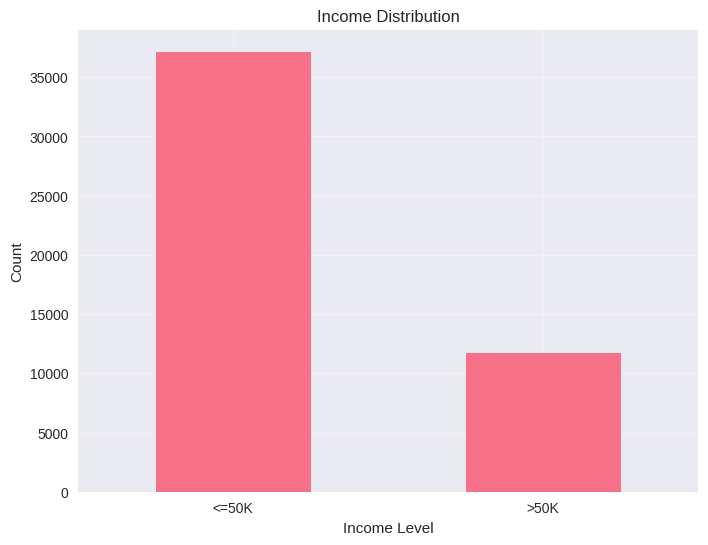

In [ ]:
# Plot the distribution of the target variable
plt.figure(figsize=(8, 6))
df['class'].value_counts().plot(kind='bar')
plt.title('Income Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

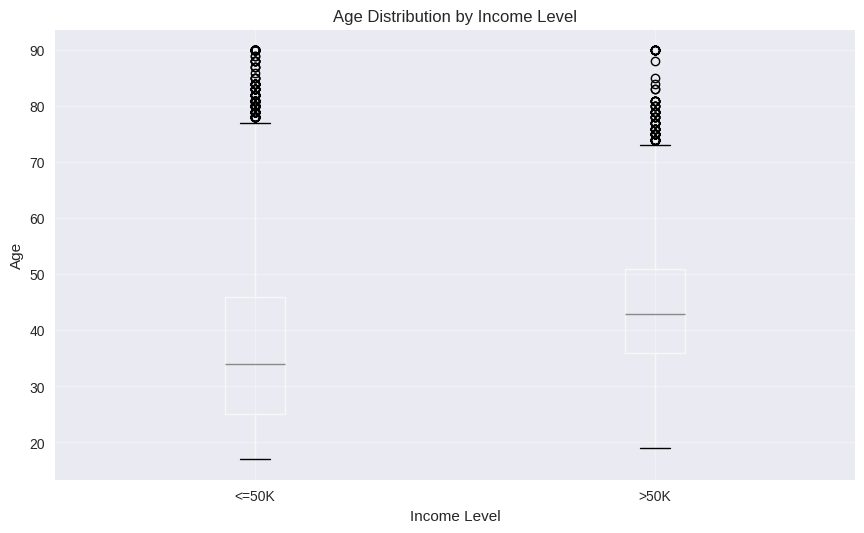

In [ ]:
# Plot the relationship between age and income
plt.figure(figsize=(10, 6))
df.boxplot(column='age', by='class', ax=plt.gca())
plt.title('Age Distribution by Income Level')
plt.suptitle('')  # Remove default title
plt.xlabel('Income Level')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1200x600 with 0 Axes>

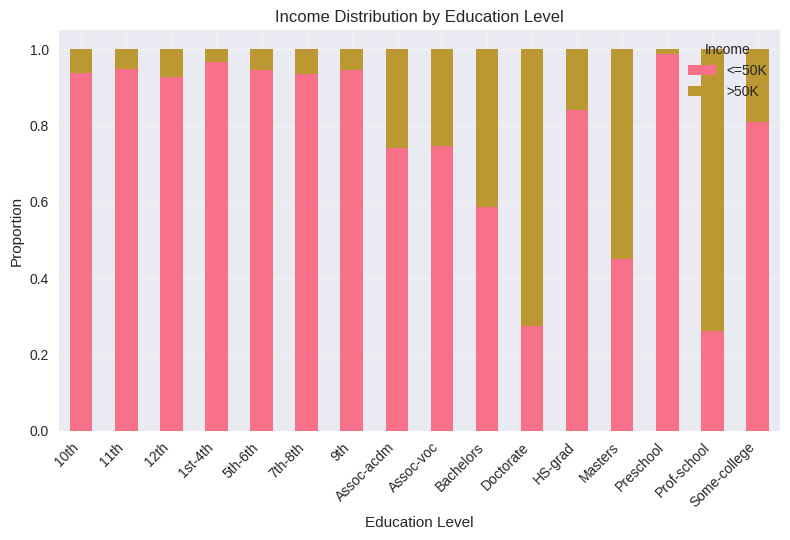

In [ ]:
# Plot the relationship between education and income
plt.figure(figsize=(12, 6))
education_income = pd.crosstab(df['education'], df['class'], normalize='index')
education_income.plot(kind='bar', stacked=True)
plt.title('Income Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion')
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

adult=fetch_openml('adult',version=2,as_frame=True)
df=adult.frame.copy()
df=df.replace('?',np.nan)
df.dropna(inplace=True)

categorical_columns=['workclass','education','marital-status','relationship','race','sex','native-country','occupation']
label_encoders={}
df_encoded=df.copy()
for col in categorical_columns:
    label_encoders[col]=LabelEncoder()
    df_encoded[col]=label_encoders[col].fit_transform(df_encoded[col])

target_encoder=LabelEncoder()
df_encoded['class']=target_encoder.fit_transform(df_encoded['class'])

x=df_encoded.drop('class',axis=1)
y=df_encoded['class']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"Training set size:{x_train.shape[0]}samples")
print(f"Testing set size:{x_test.shape[0]}samples")
print(f"Number of features:{x_train.shape[1]}")
print(f"\n Training set class distribution:")
print(f"<=50k:{sum(y_train==0)}({sum(y_train==0)/len(y_train)*100:.2f}%)")
print(f">50k:{sum(y_train==1)}({sum(y_train==1)/len(y_train)*100:.2f}%)")

Training set size:36177samples
Testing set size:9045samples
Number of features:14

 Training set class distribution:
<=50k:27172(75.11%)
>50k:9005(24.89%)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10,n_jobs=-1)
rf_classifier.fit(x_train,y_train)
print("Random Forest Classifier trained successfully!")
print("number of trees:{rf_classifier.n_estimators_}")
print(f"max depth:{rf_classifier.max_depth}")

Random Forest Classifier trained successfully!
number of trees:{rf_classifier.n_estimators_}
max depth:10


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_classifier.predict(x_test)
y_proba = rf_classifier.predict_proba(x_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8618
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      6842
           1       0.82      0.56      0.66      2203

    accuracy                           0.86      9045
   macro avg       0.84      0.76      0.79      9045
weighted avg       0.86      0.86      0.85      9045



Top 10 Feature Importances:
           Feature  Importance
10    capital-gain    0.202140
7     relationship    0.199420
4    education-num    0.151672
5   marital-status    0.139138
0              age    0.080754
11    capital-loss    0.053955
12  hours-per-week    0.049519
3        education    0.037005
6       occupation    0.030763
9              sex    0.019882


/tmp/ipython-input-4022545289.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')


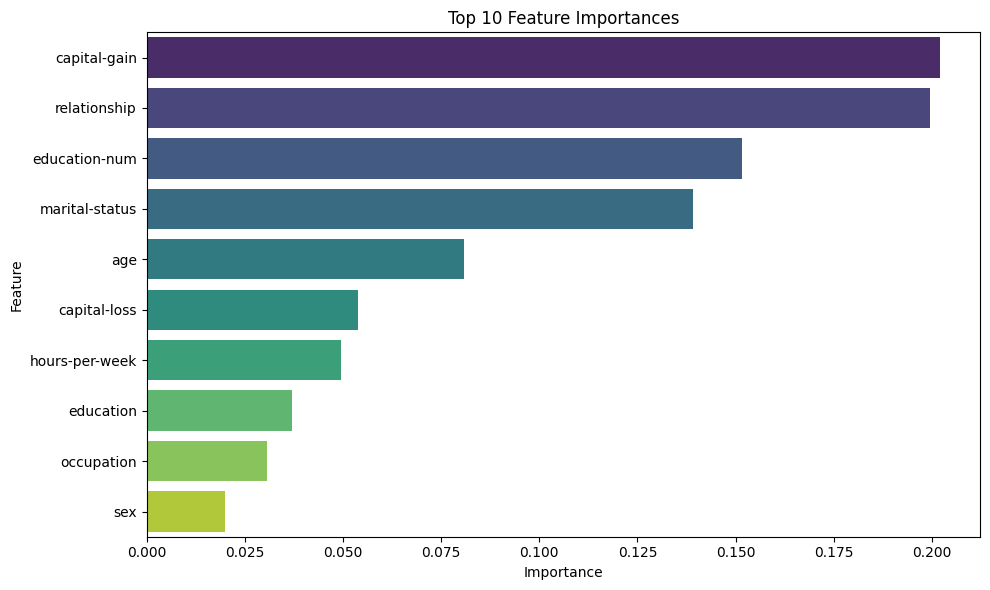

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_classifier.feature_importances_
feature_names = x.columns


feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})


feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
print(feat_imp_df.head(10))


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

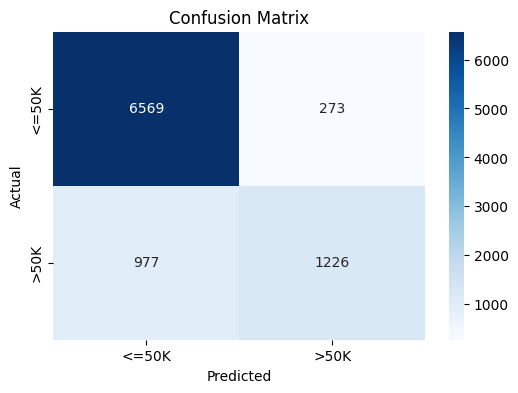

Precision: 0.8179
Recall: 0.5565
F1-score: 0.6623


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

report = classification_report(y_test, y_pred, target_names=target_encoder.classes_, output_dict=True)
precision = report['>50K']['precision']
recall = report['>50K']['recall']
f1 = report['>50K']['f1-score']
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

In [ ]:
#accuracy score
accuracy = accuracy_score(y_test, y_pred)

Accuracy of the Random Forest Classifier: 0.8618

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      6842
        >50K       0.82      0.56      0.66      2203

    accuracy                           0.86      9045
   macro avg       0.84      0.76      0.79      9045
weighted avg       0.86      0.86      0.85      9045


Confusion Matrix:


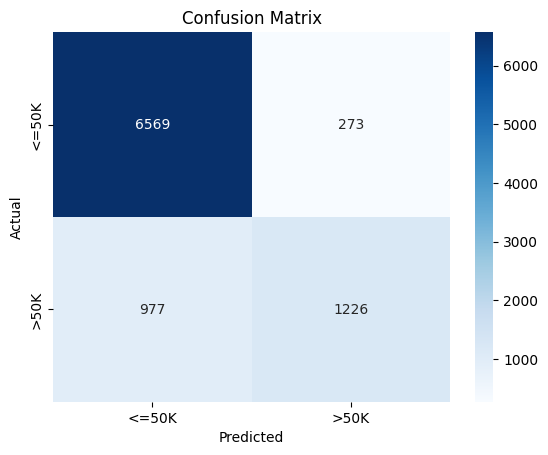

In [ ]:
y_pred = rf_classifier.predict(x_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Feature Importances:
           Feature  Importance
10    capital-gain    0.202140
7     relationship    0.199420
4    education-num    0.151672
5   marital-status    0.139138
0              age    0.080754
11    capital-loss    0.053955
12  hours-per-week    0.049519
3        education    0.037005
6       occupation    0.030763
9              sex    0.019882
2           fnlwgt    0.016082
1        workclass    0.011773
13  native-country    0.004846
8             race    0.003052


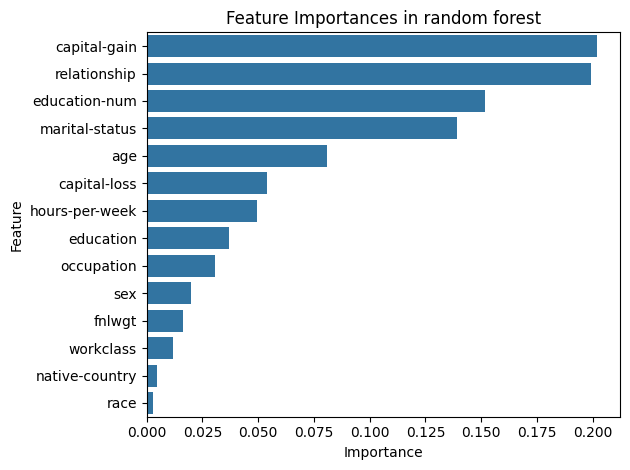

In [ ]:
#feature importance

feature_importance = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(importance_df)


#graph of feature importance
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importances in random forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = rf_classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.18%


Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      6842
           1       0.82      0.56      0.66      2203

    accuracy                           0.86      9045
   macro avg       0.84      0.76      0.79      9045
weighted avg       0.86      0.86      0.85      9045


Confusion Matrix:
[[6569  273]
 [ 977 1226]]


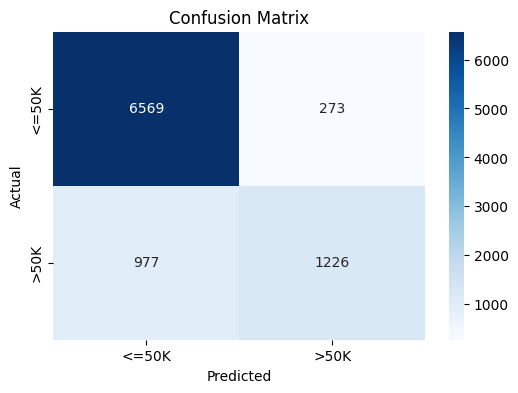

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Optionally, visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipython-input-3616588023.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


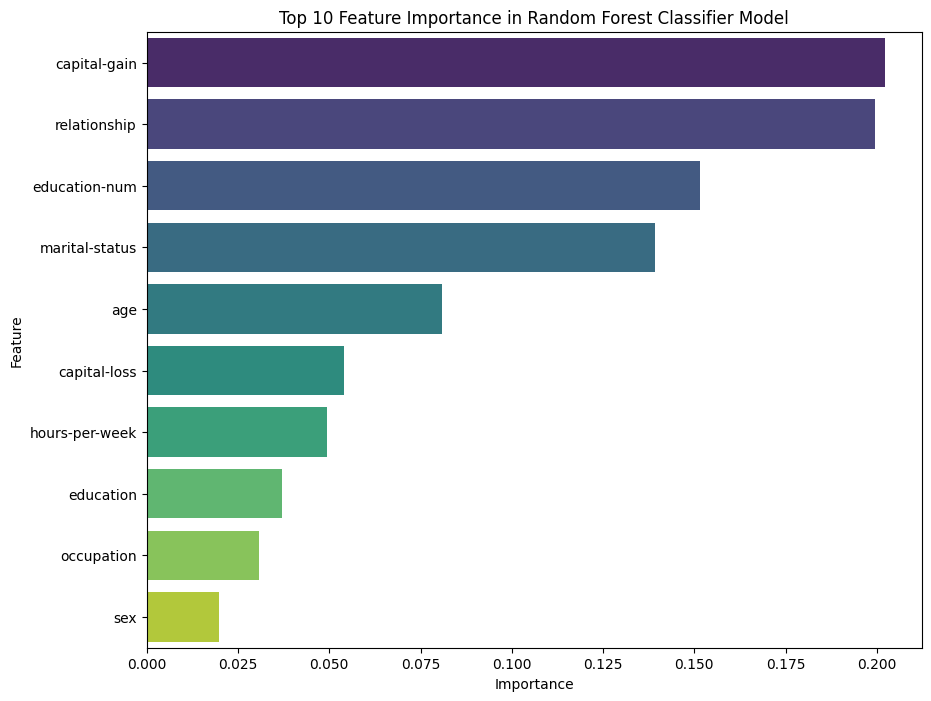

In [ ]:
# Get feature importances from the trained model
feature_importances_rf = rf_classifier.feature_importances_

# Get the names of the features from the training data
feature_names_rf = x_train.columns

# Create a DataFrame to easily visualize feature importances
importance_df_rf = pd.DataFrame({'Feature': feature_names_rf, 'Importance': feature_importances_rf})

# Sort features by importance in descending order
importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

# Select the top 10 most important features
top_10_features = importance_df_rf.head(10)

# Create a bar plot of the top 10 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Feature Importance in Random Forest Classifier Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

/tmp/ipython-input-1672015667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='coolwarm', edgecolor='black'


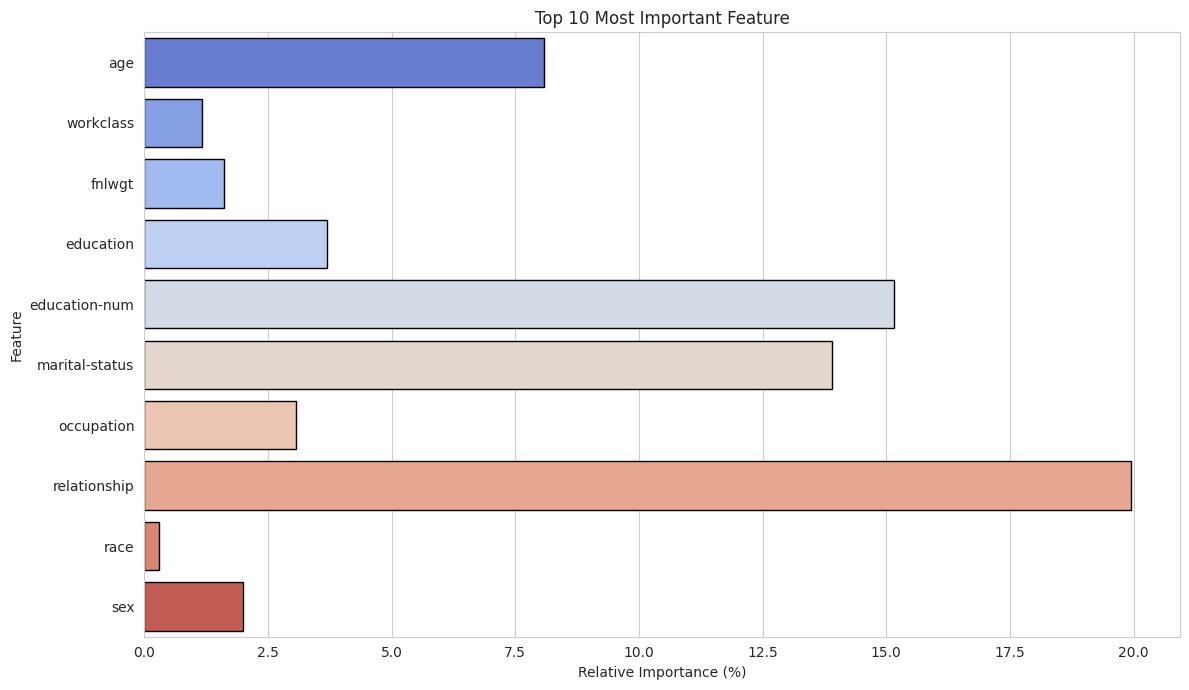

In [ ]:
importances = rf_classifier.feature_importances_
feature_names = x.columns
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feat_imp_df['Importance'] = feat_imp_df['Importance'] * 100

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='coolwarm', edgecolor='black'
)

plt.title('Top 10 Most Important Feature')
plt.xlabel('Relative Importance (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
n_estimators_range=[50,100,150,200,250]
max_depth_range=[5,10,15,20]
results=[]
for n_estimators in n_estimators_range:
    for max_depth in max_depth_range:
        rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
        rf.fit(x_train, y_train)
        accuracy=rf.score(x_test,y_test)
        results.append((n_estimators, max_depth, accuracy))

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=['n_estimators', 'max_depth', 'accuracy'])
print("Hyperparameter tuning results:")
display(results_df)

Hyperparameter tuning results:


,n_estimators,max_depth,accuracy
0,50,5,0.852515
1,50,10,0.861802
2,50,15,0.867772
3,50,20,0.864677
4,100,5,0.850304
5,100,10,0.861802
6,100,15,0.867993
7,100,20,0.864898
8,150,5,0.851631
9,150,10,0.862023


Best n_estimators: 250
Best max_depth: 15
Best accuracy: 0.87


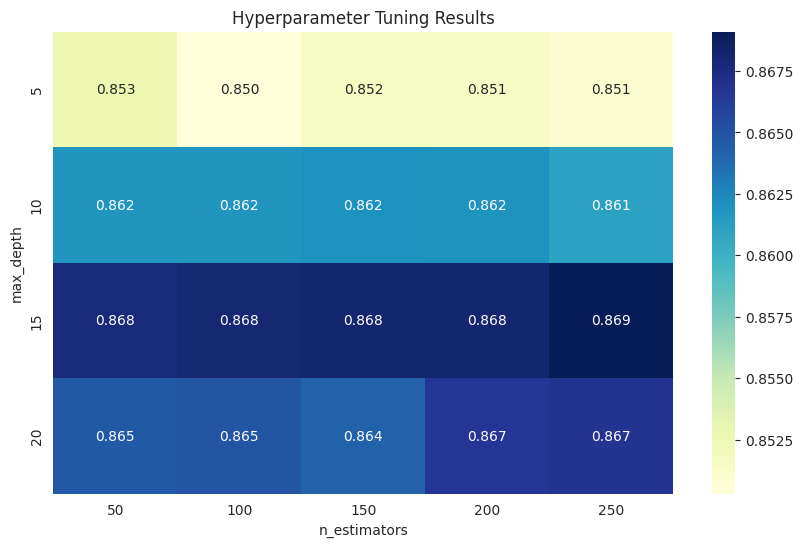

In [ ]:
best_result = max(results, key=lambda item: item[2])
print(f"Best n_estimators: {best_result[0]}")
print(f"Best max_depth: {best_result[1]}")
print(f"Best accuracy: {best_result[2]:.2f}")

# heatmap
results_df = pd.DataFrame(results, columns=['n_estimators', 'max_depth', 'accuracy'])
results_pivot = results_df.pivot(index='max_depth', columns='n_estimators', values='accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(results_pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title('Hyperparameter Tuning Results')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.show()

Best Combination:
n_estimators: 250
max_depth: 15
Accuracy: 0.8691


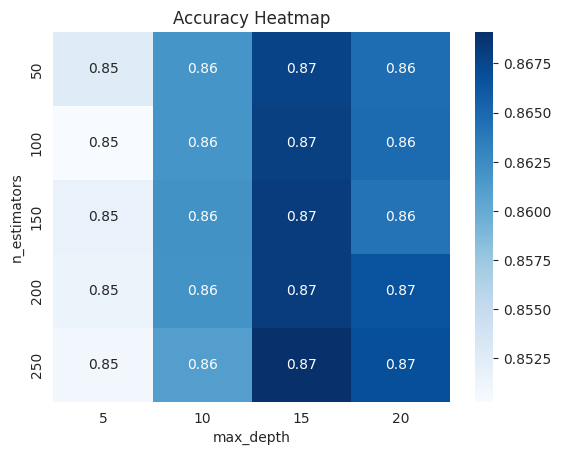

In [ ]:
best_result = results_df.loc[results_df['accuracy'].idxmax()]
print("Best Combination:")
print(f"n_estimators: {int(best_result['n_estimators'])}")
print(f"max_depth: {int(best_result['max_depth'])}")
print(f"Accuracy: {best_result['accuracy']:.4f}")

pd.pivot_table(results_df, values='accuracy', index='n_estimators', columns='max_depth')
sns.heatmap(pd.pivot_table(results_df, values='accuracy', index='n_estimators', columns='max_depth'), annot=True, cmap='Blues')
plt.title('Accuracy Heatmap')
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.show()